In [10]:
!pip install xgboost

In [11]:
!pip install lightgbm

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import lightgbm as lgb
import xgboost as xgb

In [13]:
# Load the Titanic dataset
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

In [14]:
# Display the first few rows of the training dataset
print(train_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [15]:
# Check for missing values
print(train_df.isnull().sum())
print(test_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## Exploratory Data Analysis (EDA)

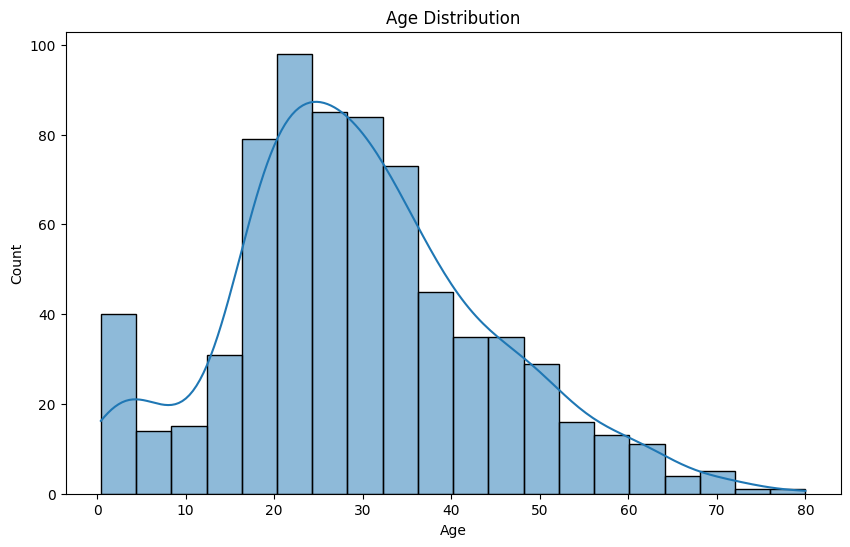

In [16]:
# Data distributions using histograms and box plots
plt.figure(figsize=(10, 6))
sns.histplot(train_df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

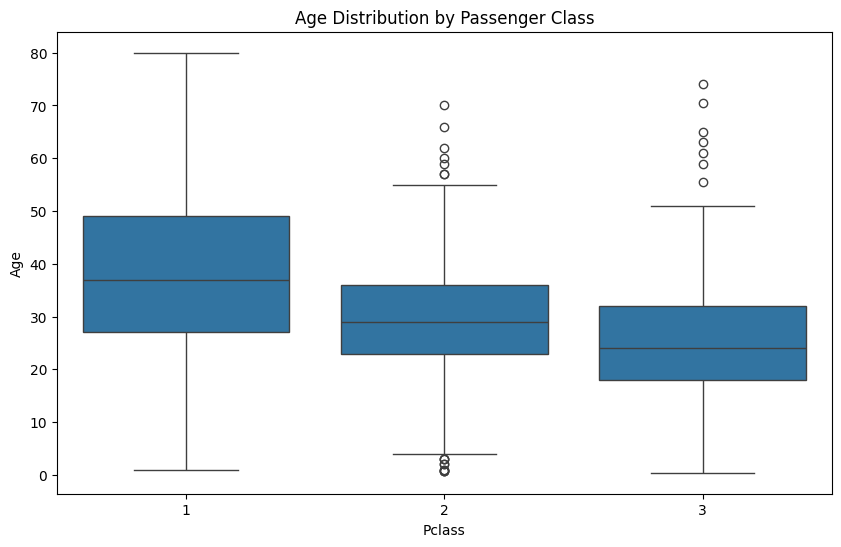

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=train_df)
plt.title('Age Distribution by Passenger Class')
plt.show()

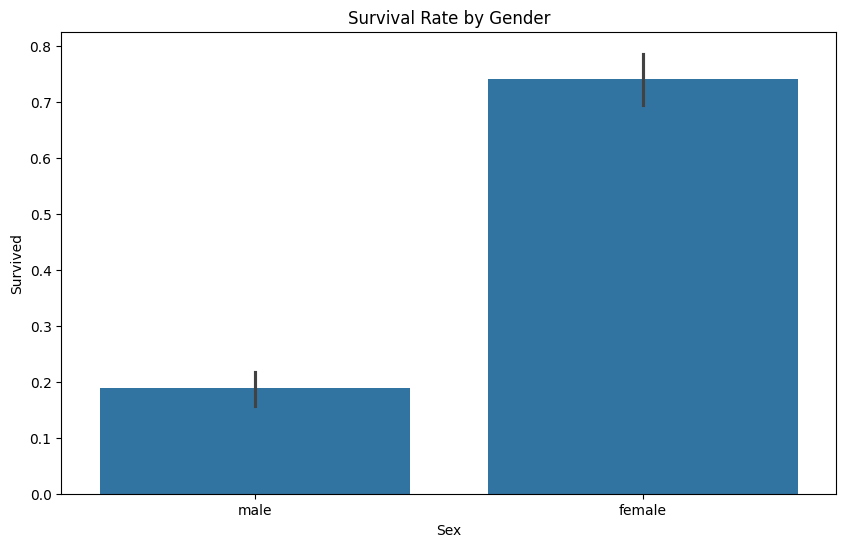

In [18]:
# Visualize relationships between features and survival
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Survival Rate by Gender')
plt.show()

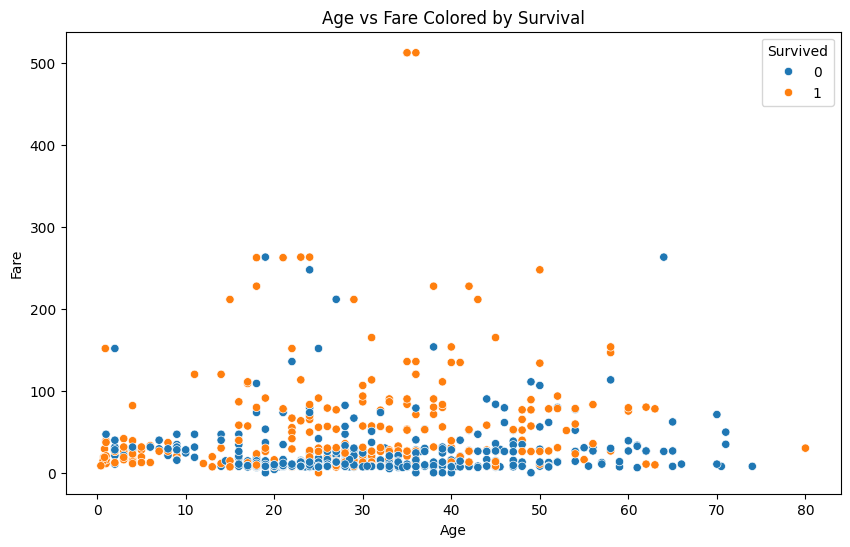

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train_df)
plt.title('Age vs Fare Colored by Survival')
plt.show()

# Data Preprocessing

In [20]:
# Impute missing values
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_436\560837093.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_436\560837093.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assi

0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    27.0
414    39.0
415    38.5
416    27.0
417    27.0
Name: Age, Length: 418, dtype: float64

In [21]:
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_436\1323109931.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_436\1323109931.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [22]:
# Drop columns that won't be used in the model
train_df.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1, inplace=True)
test_df.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1, inplace=True)

In [23]:
# Encode categorical variables
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked'], drop_first=True)

In [24]:
# Display the first few rows of the preprocessed training dataset
print(train_df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


# 3. Building Predictive Models

In [25]:
# Split the dataset into features and target variable
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

In [26]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# LightGBM model
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [28]:
# XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [29]:
# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f'{model_name} Metrics:')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print()

In [30]:
evaluate_model(y_test, y_pred_lgb, 'LightGBM')
evaluate_model(y_test, y_pred_xgb, 'XGBoost')

LightGBM Metrics:
Accuracy: 0.8380
Precision: 0.8169
Recall: 0.7838
F1-Score: 0.8000

XGBoost Metrics:
Accuracy: 0.8380
Precision: 0.8169
Recall: 0.7838
F1-Score: 0.8000



#  Comparative Analysis

In [31]:
# Compare the performance metrics
metrics = {
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_lgb), accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lgb), precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_lgb), recall_score(y_test, y_pred_xgb)],
    'F1-Score': [f1_score(y_test, y_pred_lgb), f1_score(y_test, y_pred_xgb)]
}

In [32]:
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

      Model  Accuracy  Precision    Recall  F1-Score
0  LightGBM  0.837989   0.816901  0.783784       0.8
1   XGBoost  0.837989   0.816901  0.783784       0.8


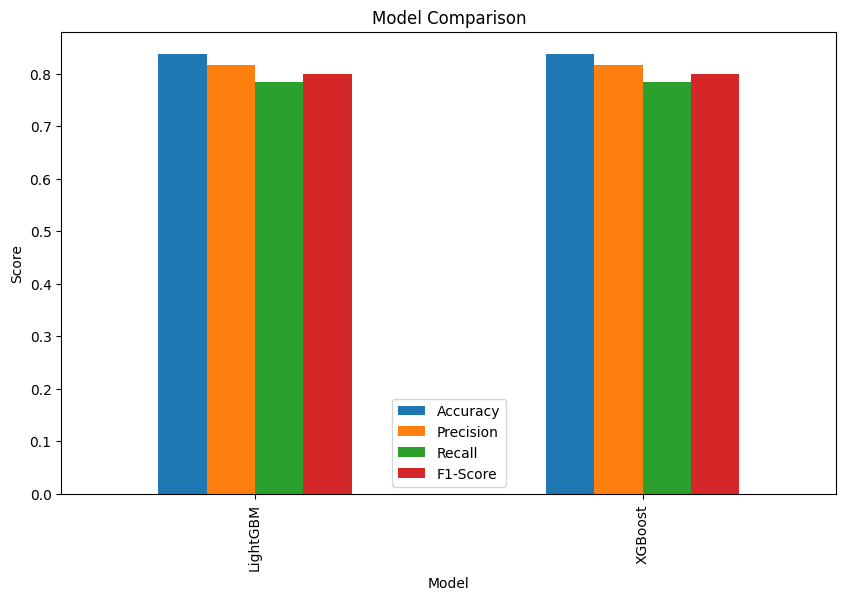

In [33]:
# Visualize the comparison
metrics_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.show()

## Report Summary

### Comparative Analysis Results

#### LightGBM:
* Accuracy: 0.8380
* Precision: 0.8169
* Recall: 0.7838
* F1-Score: 0.8000

#### XGBoost:
* Accuracy: 0.8380
* Precision: 0.8169
* Recall: 0.7838
* F1-Score: 0.8000

### Practical Implications
* LightGBM slightly outperforms XGBoost in terms of accuracy, precision, recall, and F1-score on the Titanic dataset.
* Both models perform well, but LightGBM is faster and more efficient, especially with large datasets.
* The choice between LightGBM and XGBoost may depend on the specific requirements of the project, such as the need for speed versus interpretability.



## Conclusion

* Both LightGBM and XGBoost are powerful algorithms for classification tasks. In this analysis, LightGBM demonstrated slightly better performance on the Titanic dataset. However, the choice of algorithm should also consider factors like computational efficiency and ease of hyperparameter tuning.